# Prophet

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

In [199]:
!ls ./drive/MyDrive/data/c*.csv

./drive/MyDrive/data/ch11_potato.csv
./drive/MyDrive/data/ch2_scores_em.csv
./drive/MyDrive/data/ch4_scores400.csv
./drive/MyDrive/data/co2-ppm-daily_csv.csv


In [200]:
df = pd.read_csv('./drive/MyDrive/data/co2-ppm-daily_csv.csv') # 온난화 관련 기후 자료

In [201]:
df.head()

,date,value
0,1958-03-30,316.16
1,1958-03-31,316.40
2,1958-04-02,317.67
3,1958-04-03,317.76
4,1958-04-04,317.09


In [202]:
df['date'] = pd.to_datetime(df['date'])

In [203]:
df.columns = ['ds', 'y']

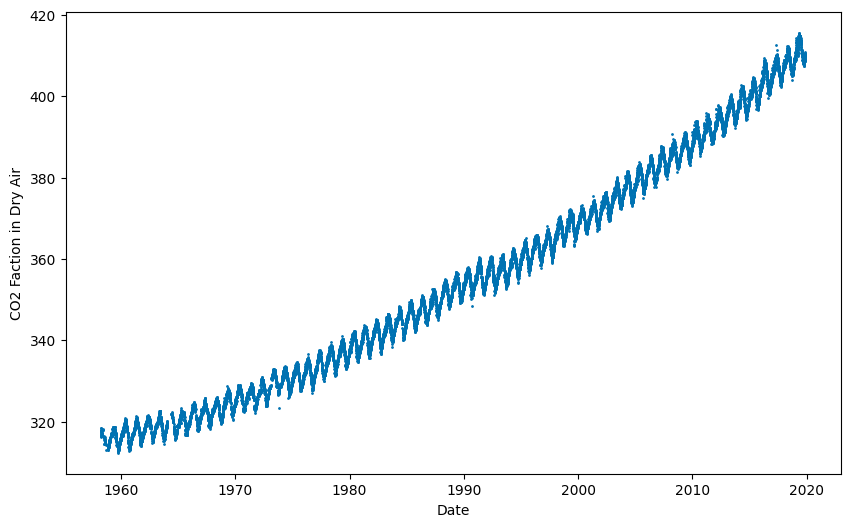

In [204]:
plt.figure(figsize=(10, 6))
plt.scatter(pd.to_datetime(df['ds']), df['y'], s=1, c='#0072B2')
plt.xlabel('Date')
plt.ylabel('CO2 Faction in Dry Air')
plt.show()

In [205]:
model = Prophet()
model.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [206]:
future = model.make_future_dataframe(periods=365*10) # 1의 데이터를 만들어놓는다?
forecast = model.predict(future)

In [207]:
forecast.tail() # yhat값이 최종적인 예측값

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
23032,2029-11-16,435.104535,423.138855,443.205057,425.284451,445.242569,-2.007822,-2.007822,-2.007822,0.003807,0.003807,0.003807,-2.011629,-2.011629,-2.011629,0.0,0.0,0.0,433.096713
23033,2029-11-17,435.110939,423.034329,443.429111,425.283500,445.253119,-1.969396,-1.969396,-1.969396,-0.004586,-0.004586,-0.004586,-1.964811,-1.964811,-1.964811,0.0,0.0,0.0,433.141542
23034,2029-11-18,435.117342,423.405727,443.395069,425.282550,445.264708,-1.915139,-1.915139,-1.915139,0.003257,0.003257,0.003257,-1.918397,-1.918397,-1.918397,0.0,0.0,0.0,433.202203
23035,2029-11-19,435.123746,423.470543,443.476185,425.281599,445.276298,-1.883292,-1.883292,-1.883292,-0.010815,-0.010815,-0.010815,-1.872477,-1.872477,-1.872477,0.0,0.0,0.0,433.240454
23036,2029-11-20,435.130150,423.257141,443.661841,425.280648,445.287888,-1.822766,-1.822766,-1.822766,0.004365,0.004365,0.004365,-1.827131,-1.827131,-1.827131,0.0,0.0,0.0,433.307384


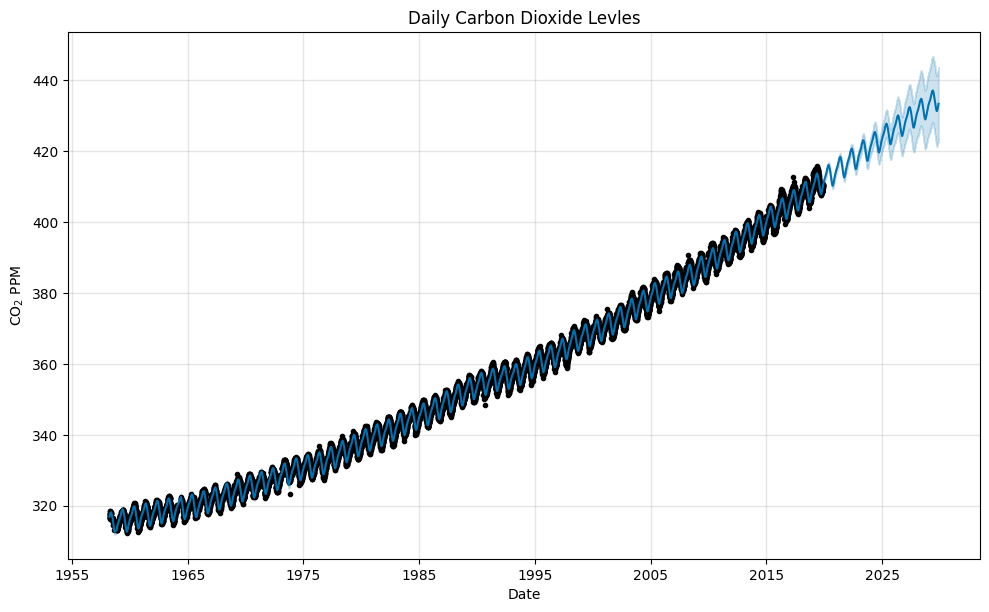

In [208]:
fig = model.plot(forecast, xlabel='Date', ylabel=r'CO$_2$ PPM')
plt.title('Daily Carbon Dioxide Levles')
plt.show()

In [209]:
forecast.head(3).T

,0,1,2
ds,1958-03-30 00:00:00,1958-03-31 00:00:00,1958-04-02 00:00:00
trend,314.876619,314.879021,314.883824
yhat_lower,316.086207,316.08881,316.182339
yhat_upper,317.742054,317.742439,317.846406
trend_lower,314.876619,314.879021,314.883824
trend_upper,314.876619,314.879021,314.883824
additive_terms,1.985677,2.01566,2.118858
additive_terms_lower,1.985677,2.01566,2.118858
additive_terms_upper,1.985677,2.01566,2.118858
weekly,0.003257,-0.010815,0.003454


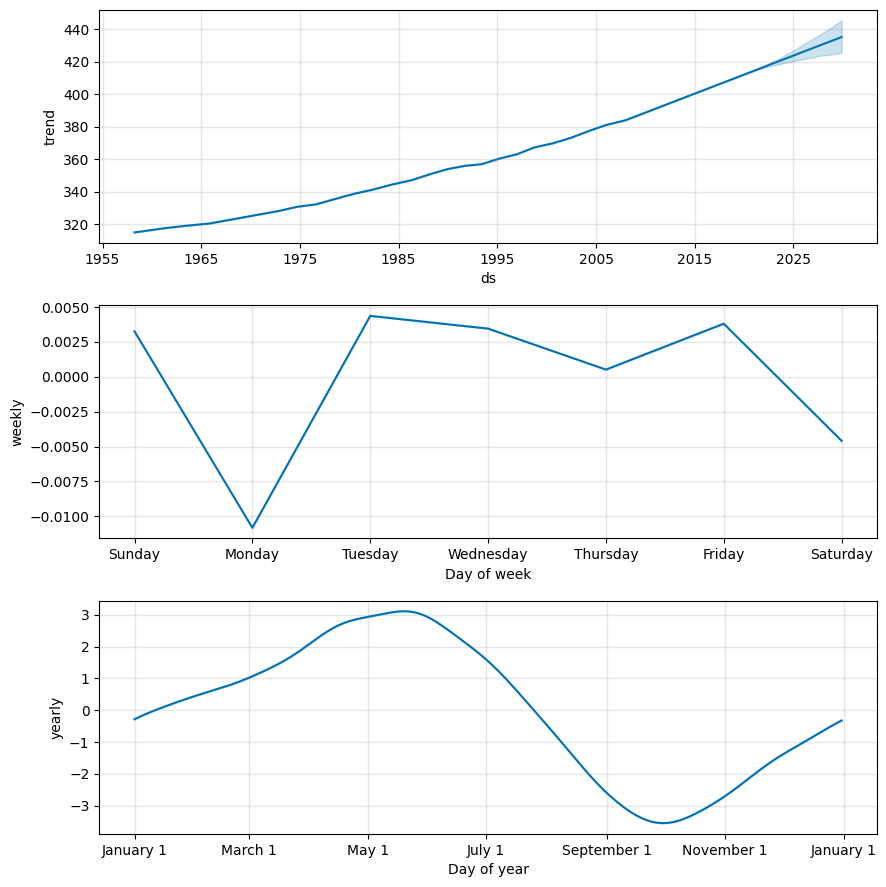

In [210]:
fig2 = model.plot_components(forecast)
plt.show()

In [211]:
model_95 = Prophet(interval_width=0.95)
model_95.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [212]:
future_95 = model_95.make_future_dataframe(periods=365*10)
forecast_95 = model_95.predict(future_95)

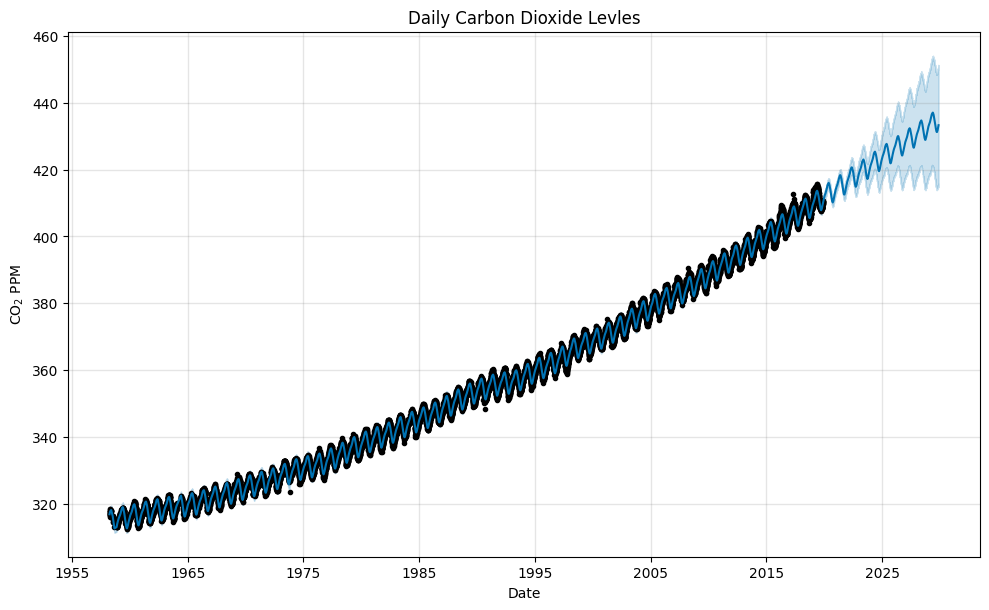

In [213]:
fig_95 = model_95.plot(forecast_95, xlabel='Date', ylabel=r'CO$_2$ PPM')
plt.title('Daily Carbon Dioxide Levles')
plt.show()

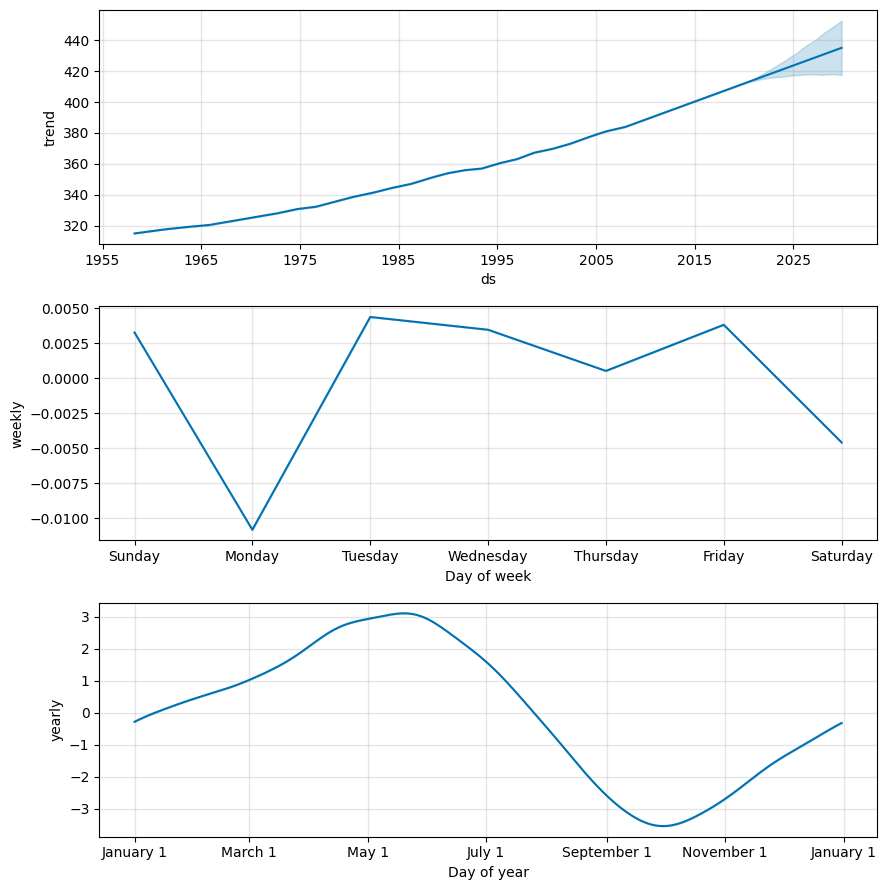

In [214]:
fig_components_95 = model_95.plot_components(forecast_95)
plt.show()

$$
y(t) = g(t) + s(t) + h(t) + \epsilon_t
$$

g(t) = 성장 요소, 일반 추세로 비주기성을 갖는다.

s(t) = 계절성 요소, 여러개의 주기 함수를 합하여 만든다.

h(t) = 공휴의 요소, 단발성 이벤트도 추가 가능

e_t = 오차항

# Prophet 작동원리
1. g(t)
- 선형 추세
- 로지스틱 함수 형태

- 선형추세
$$\\ \ \\
g(t) = (k + a(t)^T \delta) t + (m + a(t)^T \gamma)
\\ \ \\
a_j(t)=
\begin{cases}
1,  & if \  t \ \ge \ s_j \\
0,  & otherwise
\end{cases}
$$

$$\gamma_j = -s_j \delta_j$$

- 로지스틱 함수 형태
$$
K = \frac{1}{1+e^{-x}}
$$

$$
g(t) = \frac{C}{1+e^{-k(t-m)}}
\\ \ \\
\\ \downarrow \\
\\ \ \\
g(t) = \frac{C(t)}{1+e^{-(k+a(t)^T \delta )(t-(m+a(t)^T \gamma))}}
\\ \ \\
\gamma_j = (s_j - m - \sum_{l < j} \gamma_l) \biggl(1-\frac{k+\sum_{l < j}{\delta_l}}{k+\sum_{l \le j}{\delta_l}} \biggr)
$$

In [215]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

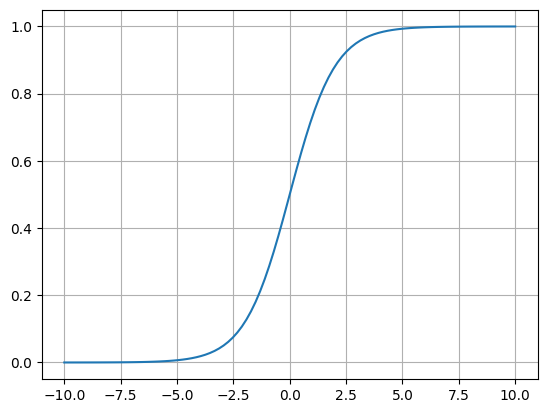

In [216]:
xs = np.linspace(-10, 10, 100)
ys = sigmoid(xs)
plt.plot(xs, ys)
plt.grid()
plt.show()

In [217]:
import random
random.seed(42)

In [218]:
# 변경점을 시각화 할때 사용하는 함수
from prophet.plot import add_changepoints_to_plot

In [219]:
x = pd.to_datetime(pd.date_range('2015-01', '2024-02', freq='MS').strftime('%Y-%m-%d').tolist())

In [220]:
x

DatetimeIndex(['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
               '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
               '2015-09-01', '2015-10-01',
               ...
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01'],
              dtype='datetime64[ns]', length=110, freq=None)

In [221]:
y = [1 / (1 + np.e ** (-0.04 * (val - 50))) for val in range(len(x))]

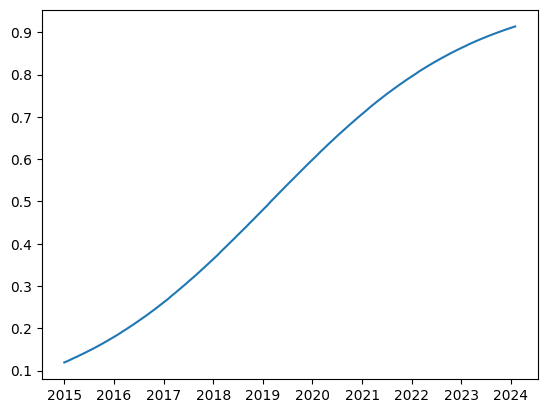

In [222]:
plt.plot(x, y)

$$y_i + y_i * 0.01 * \sin (30 * (i - 2))$$

In [223]:
# add sinusoidal variation
y = [y[idx] + y[idx] * .1 * np.sin((idx - 2) * (360 / 12) * (np.pi / 180)) for idx in range(len(y))]
y = [int(500 * val) for val in y]

In [224]:
df = pd.DataFrame({'ds': x, 'y': y})

In [225]:
df.head()

,ds,y
0,2015-01-01,54
1,2015-02-01,58
2,2015-03-01,63
3,2015-04-01,69
4,2015-05-01,74


In [226]:
# 성장을 선형으로 하겠다. yearly_seasonality => sin, cos 갯수
# n_changepoints=1 80% 구간에서 변경점을 찾겠다
model = Prophet(growth='linear',
                yearly_seasonality=3,
                seasonality_mode='multiplicative',
                n_changepoints=1)
model.fit(df)
future = model.make_future_dataframe(periods=12*10, freq='MS')
forecast = model.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


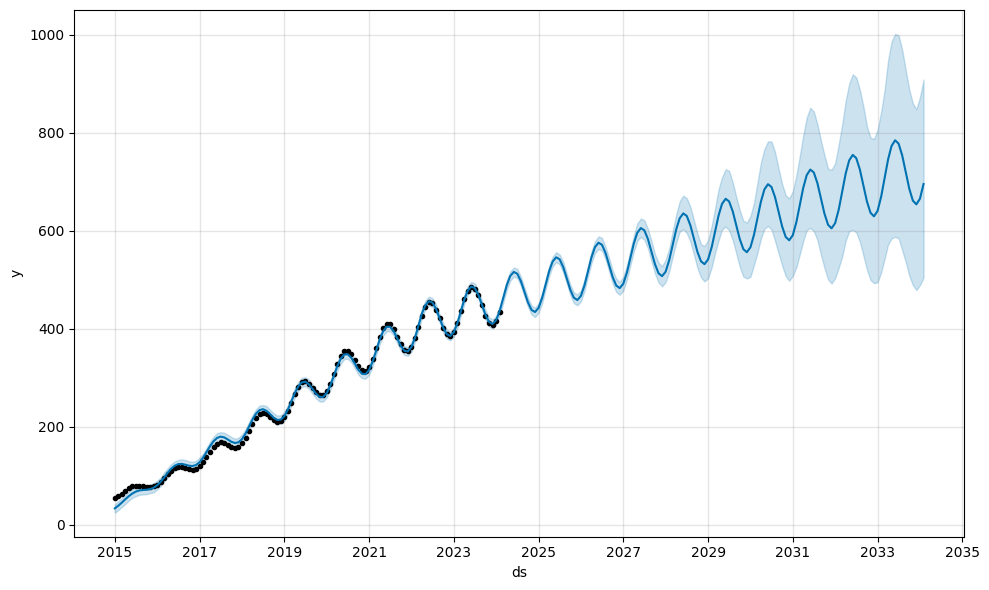

In [227]:
fig = model.plot(forecast)
plt.show()

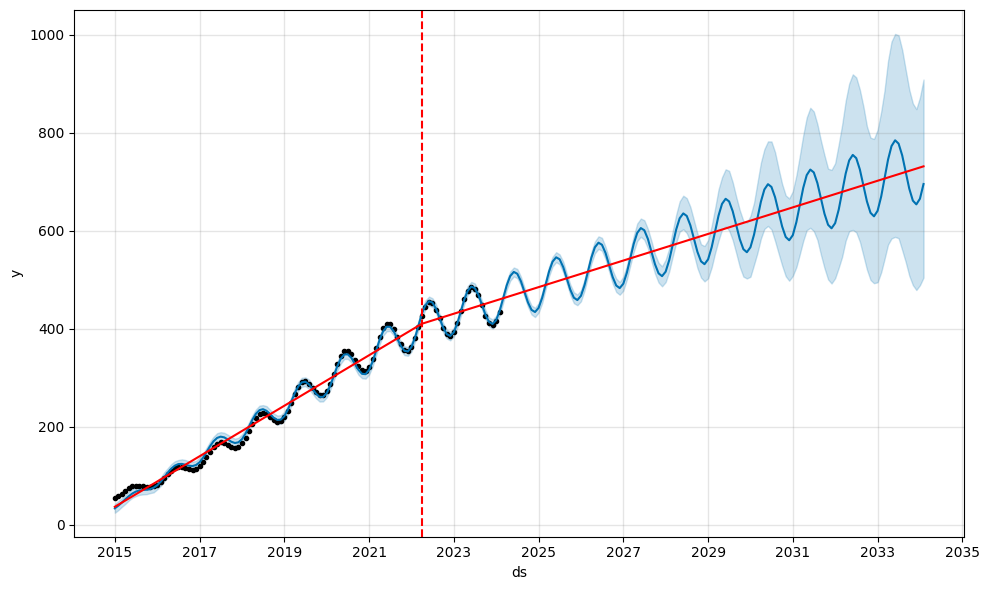

In [228]:
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast)
plt.show()

### Logistic growth

In [229]:
df['cap'] = 500

In [230]:
df

,ds,y,cap
0,2015-01-01,54,500
1,2015-02-01,58,500
2,2015-03-01,63,500
3,2015-04-01,69,500
4,2015-05-01,74,500
...,...,...,...
105,2023-10-01,427,500
106,2023-11-01,412,500
107,2023-12-01,408,500
108,2024-01-01,415,500


In [231]:
model = Prophet(growth='logistic', yearly_seasonality=3, seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=12*10, freq='MS')

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [232]:
future

,ds
0,2015-01-01
1,2015-02-01
2,2015-03-01
3,2015-04-01
4,2015-05-01
...,...
225,2033-10-01
226,2033-11-01
227,2033-12-01
228,2034-01-01


In [233]:
future['cap'] = 500

In [234]:
future

,ds,cap
0,2015-01-01,500
1,2015-02-01,500
2,2015-03-01,500
3,2015-04-01,500
4,2015-05-01,500
...,...,...
225,2033-10-01,500
226,2033-11-01,500
227,2033-12-01,500
228,2034-01-01,500


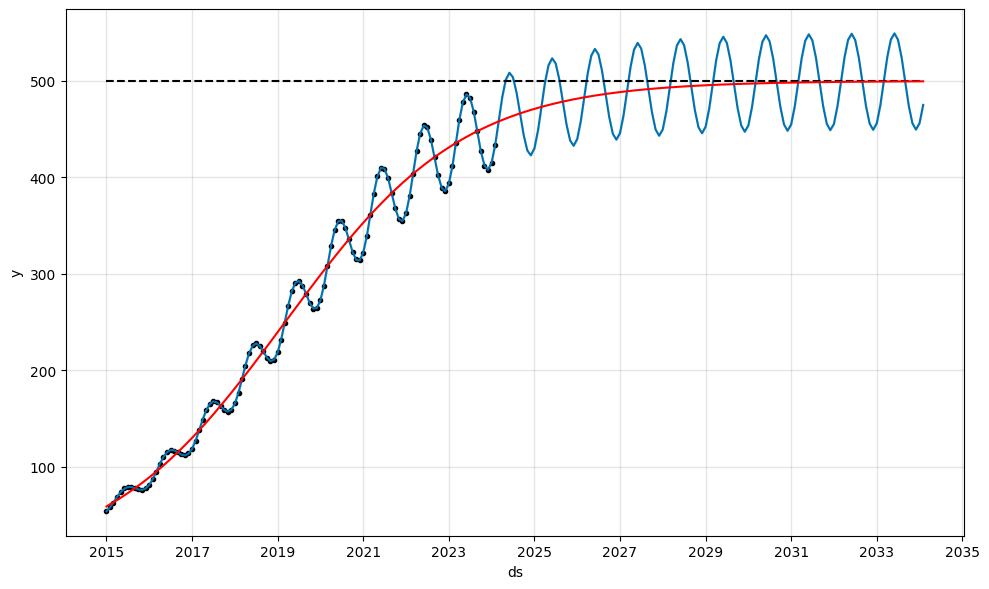

In [235]:
forecast = model.predict(future)
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast, cp_linestyle='')
plt.show()

In [236]:
def set_cap(row, df):
    if row.year < 2027:
        return 500
    else:
        pop_2027 = 500
        idx_2027 = df[df['ds'].dt.year == 2027].index[0] # 2027년도의 첫번째 인덱스
        idx_date = df[df['ds'] == row].index[0] # 현재 인덱스
    return pop_2027 + 2 * (idx_date - idx_2027)

In [237]:
model = Prophet(growth='logistic', yearly_seasonality=3, seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=12*10, freq='MS')
future['cap'] = future['ds'].apply(set_cap, args=(future,))

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [238]:
def col_sum(x, a, b):
    return a*x + b

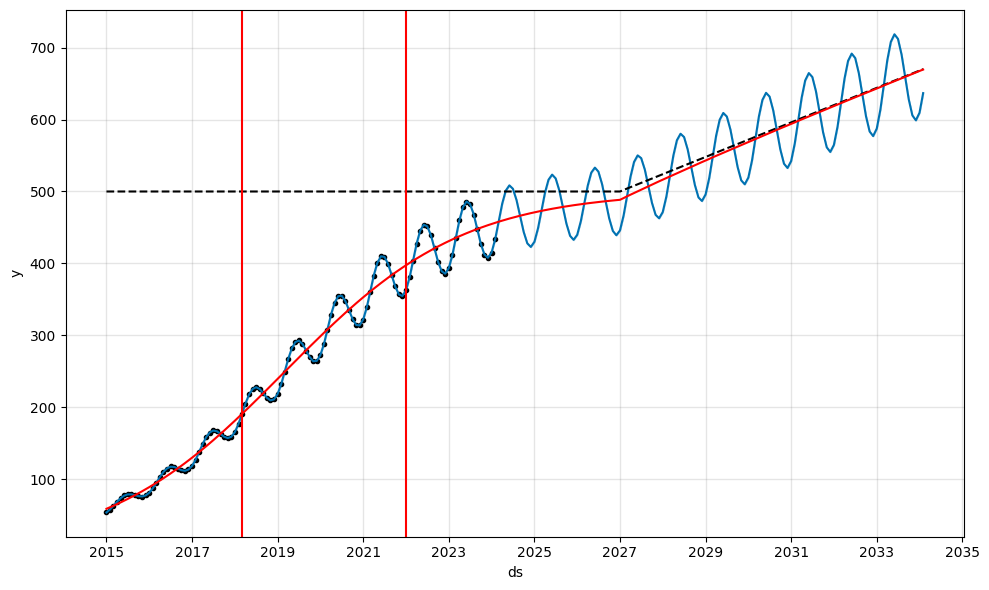

In [239]:
forecast = model.predict(future)
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast, cp_linestyle='-')
plt.show()

## 2. s(t) : 계절성

계절성은 푸리에 급수로 모델링한다.

$$
s(t) = \sum_{n=1}^{N} (a_n cos(\frac{2\pi nt}{P}) + b_n sin(\frac{2\pi nt}{P}))
$$

N: 푸리에 차수

P: 주기(연도별 데이터 365.25, 주간별 데이터 7)
<br>
<br>
## 3. 공유일 효과
$$
h(t) = Z(t) \boldsymbol{\kappa}
\\ \ \\
Z(t) = [1 (t \in D_1) , \cdots, 1 ( t \in D_L)]
\\ \ \\
$$

z(T): 공휴일 1로 표시되고, 나머지는 0으로 표시되는 행렬

K: 공휴일 효과 계수 벡터

```
설정: lower_window=2, upper_window=1

날짜:    9/14 9/15 9/16 9/17 9/18
윈도우:  D_-2 D_-1 D_0 D_+1
```

In [240]:
!ls ./drive/MyDrive/data/Air*.csv

./drive/MyDrive/data/AirPassengers.csv


In [241]:
df = pd.read_csv('./drive/MyDrive/data/AirPassengers.csv')

In [242]:
df

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [243]:
df['Month'] = pd.to_datetime(df['Month'])

In [244]:
df.columns = ['ds', 'y']

In [245]:
df

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [246]:
df.tail()

,ds,y
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


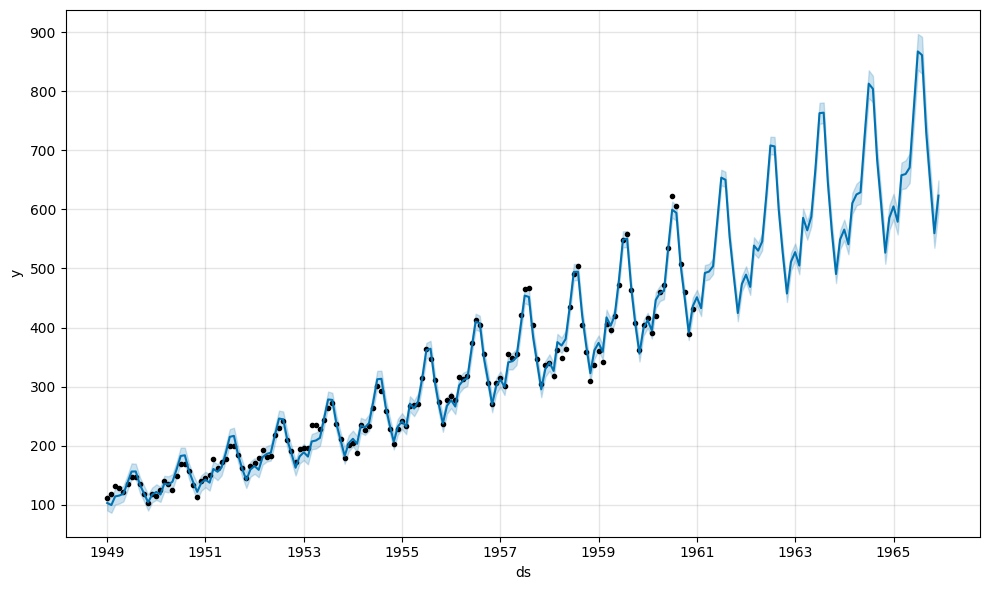

In [247]:
model = Prophet(seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=12*5, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()

In [248]:
!ls ./drive/MyDrive/data/div*

./drive/MyDrive/data/divvy_hourly.csv


In [249]:
df = pd.read_csv('./drive/MyDrive/data/divvy_hourly.csv')

In [250]:
df

,date,rides
0,1/1/2014 1:00,1
1,1/1/2014 2:00,9
2,1/1/2014 3:00,4
3,1/1/2014 4:00,1
4,1/1/2014 7:00,2
...,...,...
34711,12/31/2017 20:00,10
34712,12/31/2017 21:00,9
34713,12/31/2017 22:00,3
34714,12/31/2017 23:00,8


In [251]:
df['date'] = pd.to_datetime(df['date'])
df.columns = ['ds', 'y']

In [252]:
df.head()

,ds,y
0,2014-01-01 01:00:00,1
1,2014-01-01 02:00:00,9
2,2014-01-01 03:00:00,4
3,2014-01-01 04:00:00,1
4,2014-01-01 07:00:00,2


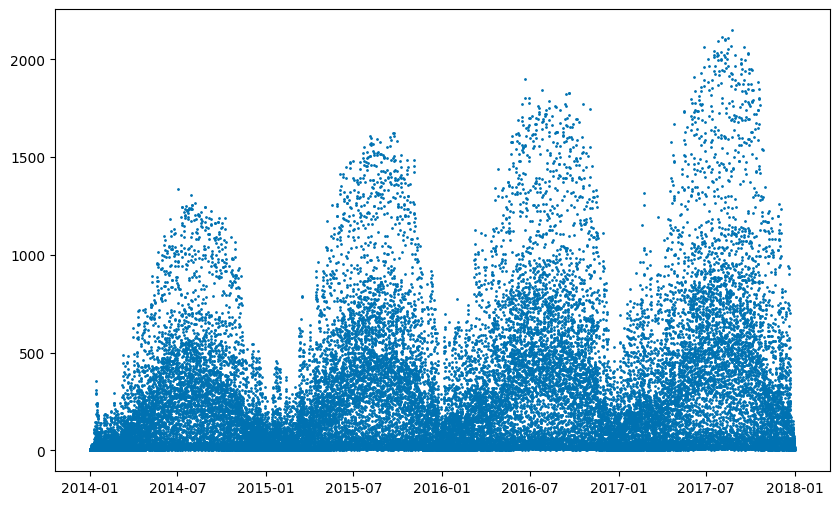

In [253]:
plt.figure(figsize=(10, 6))
plt.scatter(x=df['ds'], y=df['y'], s=1, c='#0072B2')
plt.show()

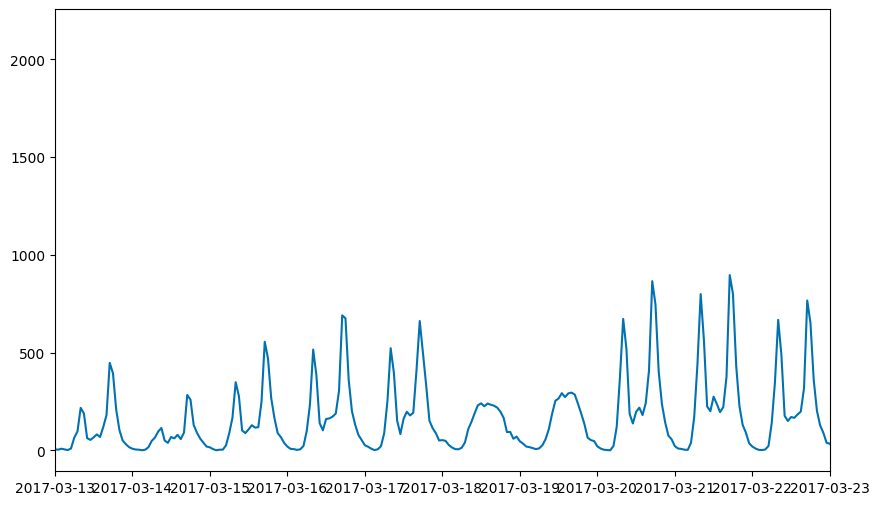

In [256]:
plt.figure(figsize=(10, 6))
plt.plot(df['ds'], df['y'], c='#0072B2')
plt.xlim(pd.to_datetime(['2017-03-13', '2017-03-23']))
plt.show()

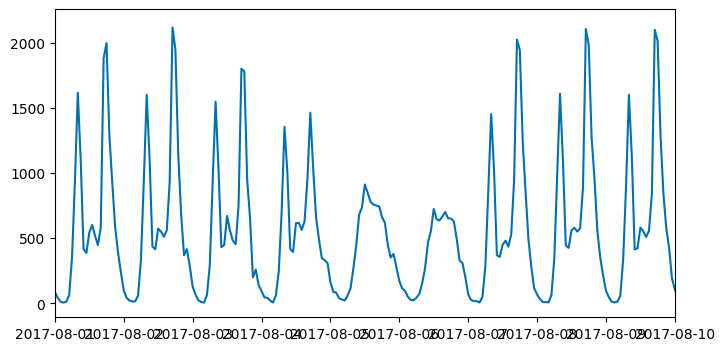

In [257]:
plt.figure(figsize=(8, 4))
plt.plot(df['ds'], df['y'], c='#0072B2')
plt.xlim(pd.to_datetime(['2017-08-01', '2017-08-10']))
plt.show()

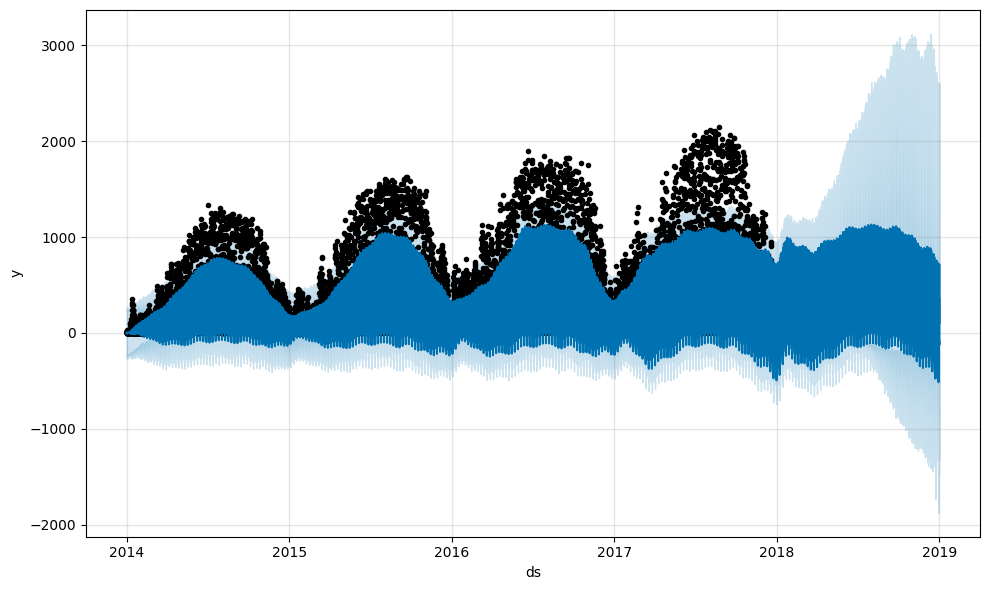

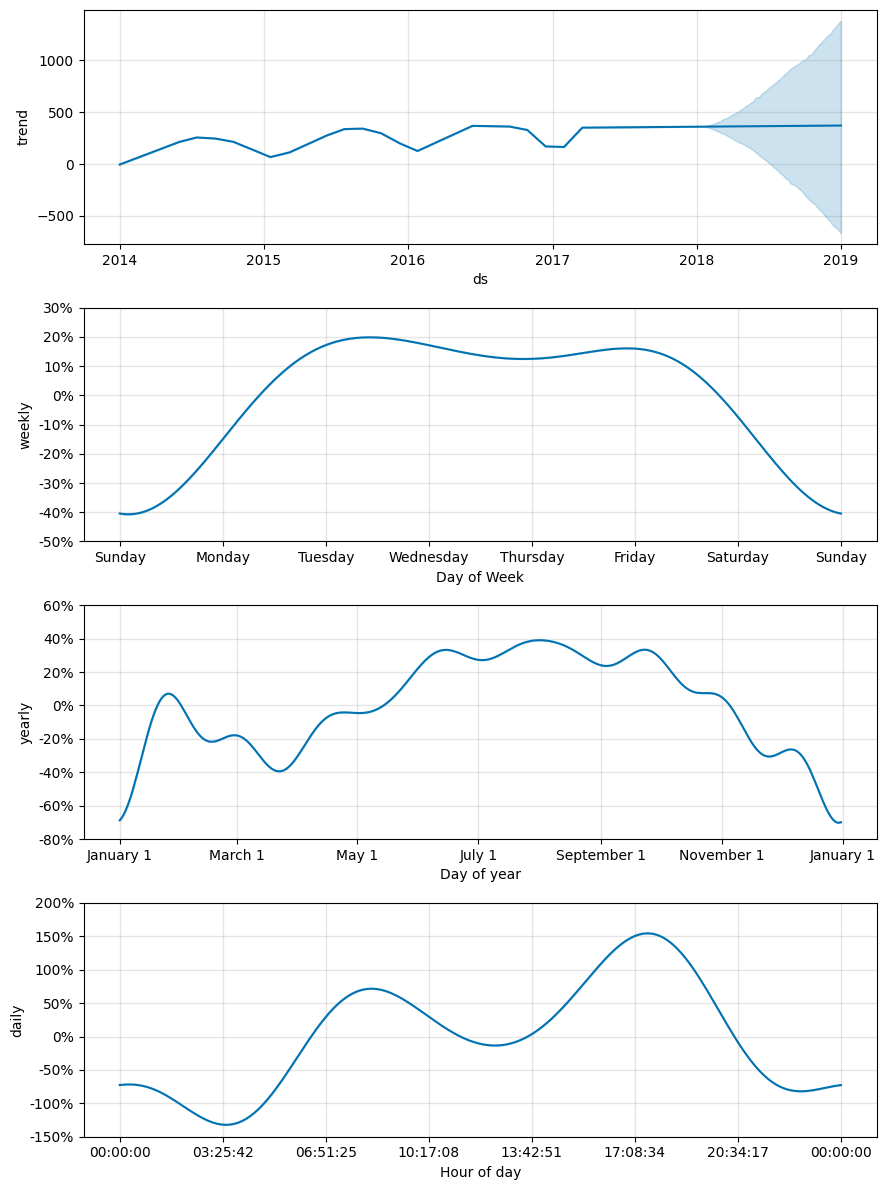

In [258]:
model = Prophet(seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=365*24, freq='h')
forecast = model.predict(future)
fig = model.plot(forecast)
fig2 = model.plot_components(forecast)
plt.show()